In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
df = pd.read_csv('webtraffic.csv')

In [3]:
# EDA

In [4]:
df.head()

,Hour Index,Sessions
0,0,1418159421
1,1,1113769116
2,2,919158921
3,3,822352824
4,4,735526737


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4896 entries, 0 to 4895
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Hour Index  4896 non-null   int64
 1   Sessions    4896 non-null   int64
dtypes: int64(2)
memory usage: 76.6 KB


In [6]:
df.isnull().sum()

Hour Index    0
Sessions      0
dtype: int64

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hour Index,4896.0,2.447500e+03,1.413498e+03,0.0,1.223750e+03,2.447500e+03,3.671250e+03,4.895000e+03
Sessions,4896.0,2.249544e+09,9.064586e+08,570856572.0,1.528938e+09,2.086820e+09,2.974043e+09,6.061858e+09


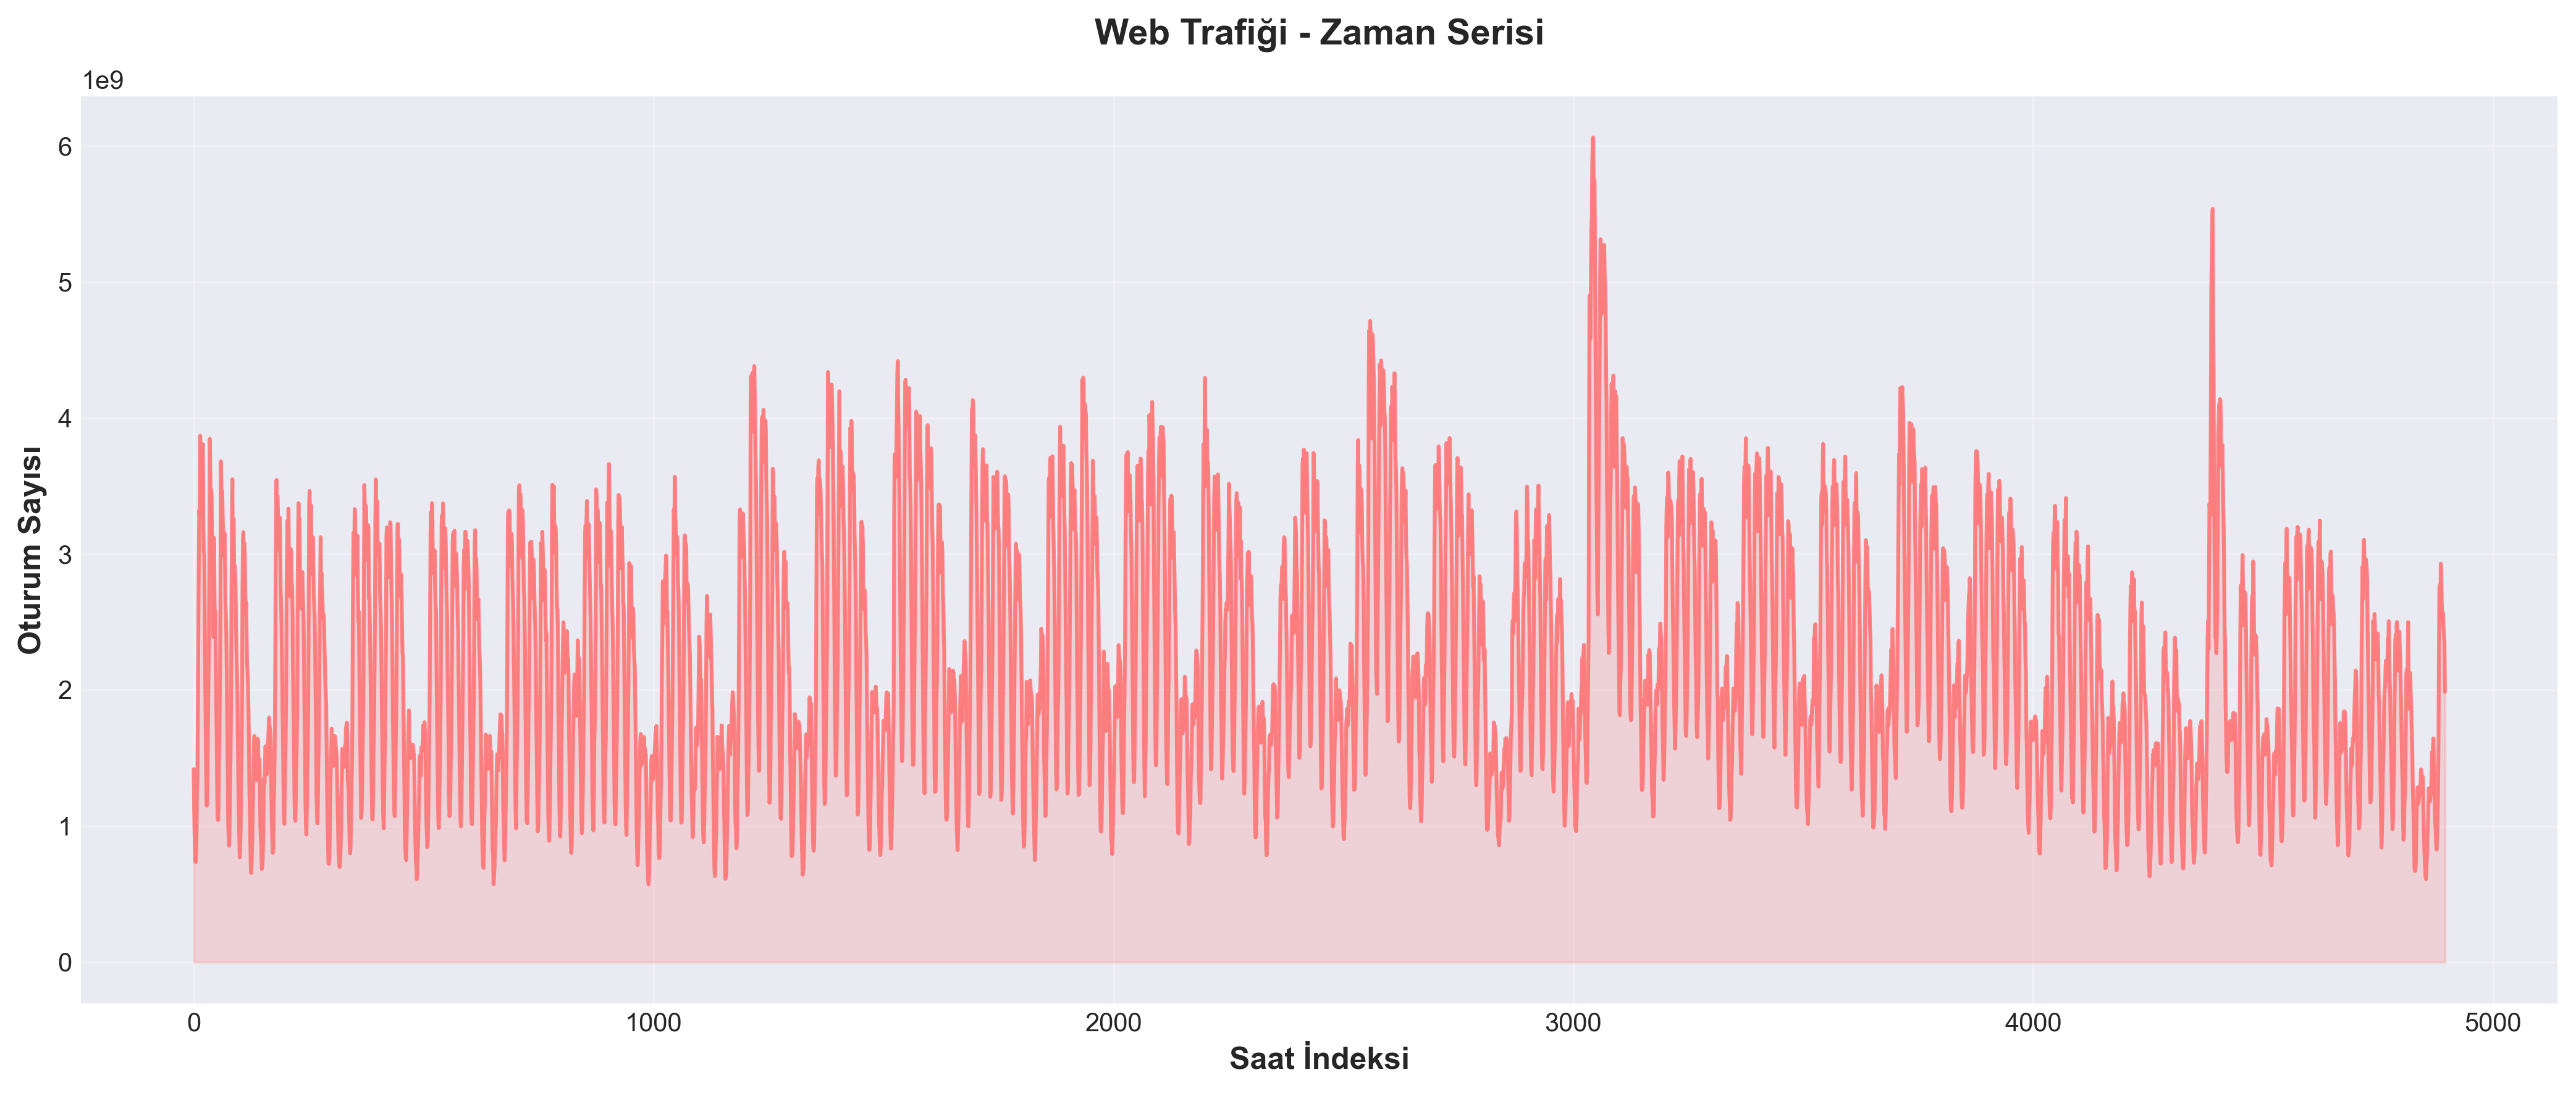

In [9]:
# Zaman serisi
plt.figure(figsize=(14, 6), dpi=300)
plt.plot(df['Hour Index'], df['Sessions'], color='#FF6B6B', linewidth=1.5, alpha=0.8)
plt.fill_between(df['Hour Index'], df['Sessions'], alpha=0.2, color='#FF6B6B')
plt.xlabel('Saat İndeksi', fontsize=12, fontweight='bold')
plt.ylabel('Oturum Sayısı', fontsize=12, fontweight='bold')
plt.title('Web Trafiği - Zaman Serisi', fontsize=14, fontweight='bold', pad=20)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

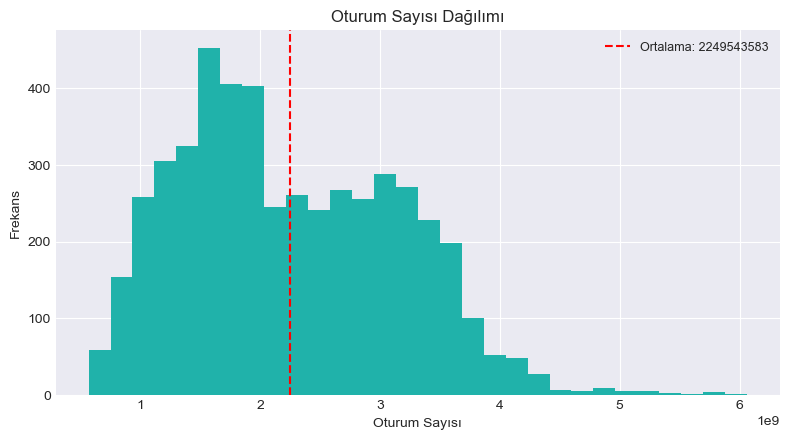

In [12]:
# Oturum dağılımı
plt.figure(figsize=(8, 4.5))
plt.hist(df['Sessions'].dropna(), bins=30, color='#20B2AA')
plt.axvline(df['Sessions'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Ortalama: {df['Sessions'].mean():.0f}")
plt.xlabel('Oturum Sayısı')
plt.ylabel('Frekans')
plt.title('Oturum Sayısı Dağılımı')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Scaler oluştur ve verileri normalize et
scaler = MinMaxScaler(feature_range=(0, 1))
df_normalized = scaler.fit_transform(df[['Sessions']])

In [15]:
df_normalized[:5]

array([[0.15430752],
       [0.09887314],
       [0.06343148],
       [0.04580153],
       [0.02998909]])

In [16]:
# %80 train, %20 test olarak böl
train_size = int(len(df_normalized) * 0.8)
train = df_normalized[:train_size]
test = df_normalized[train_size:]

In [18]:
from statsmodels.tsa.stattools import adfuller

# ADF testi
result = adfuller(df['Sessions'].dropna())

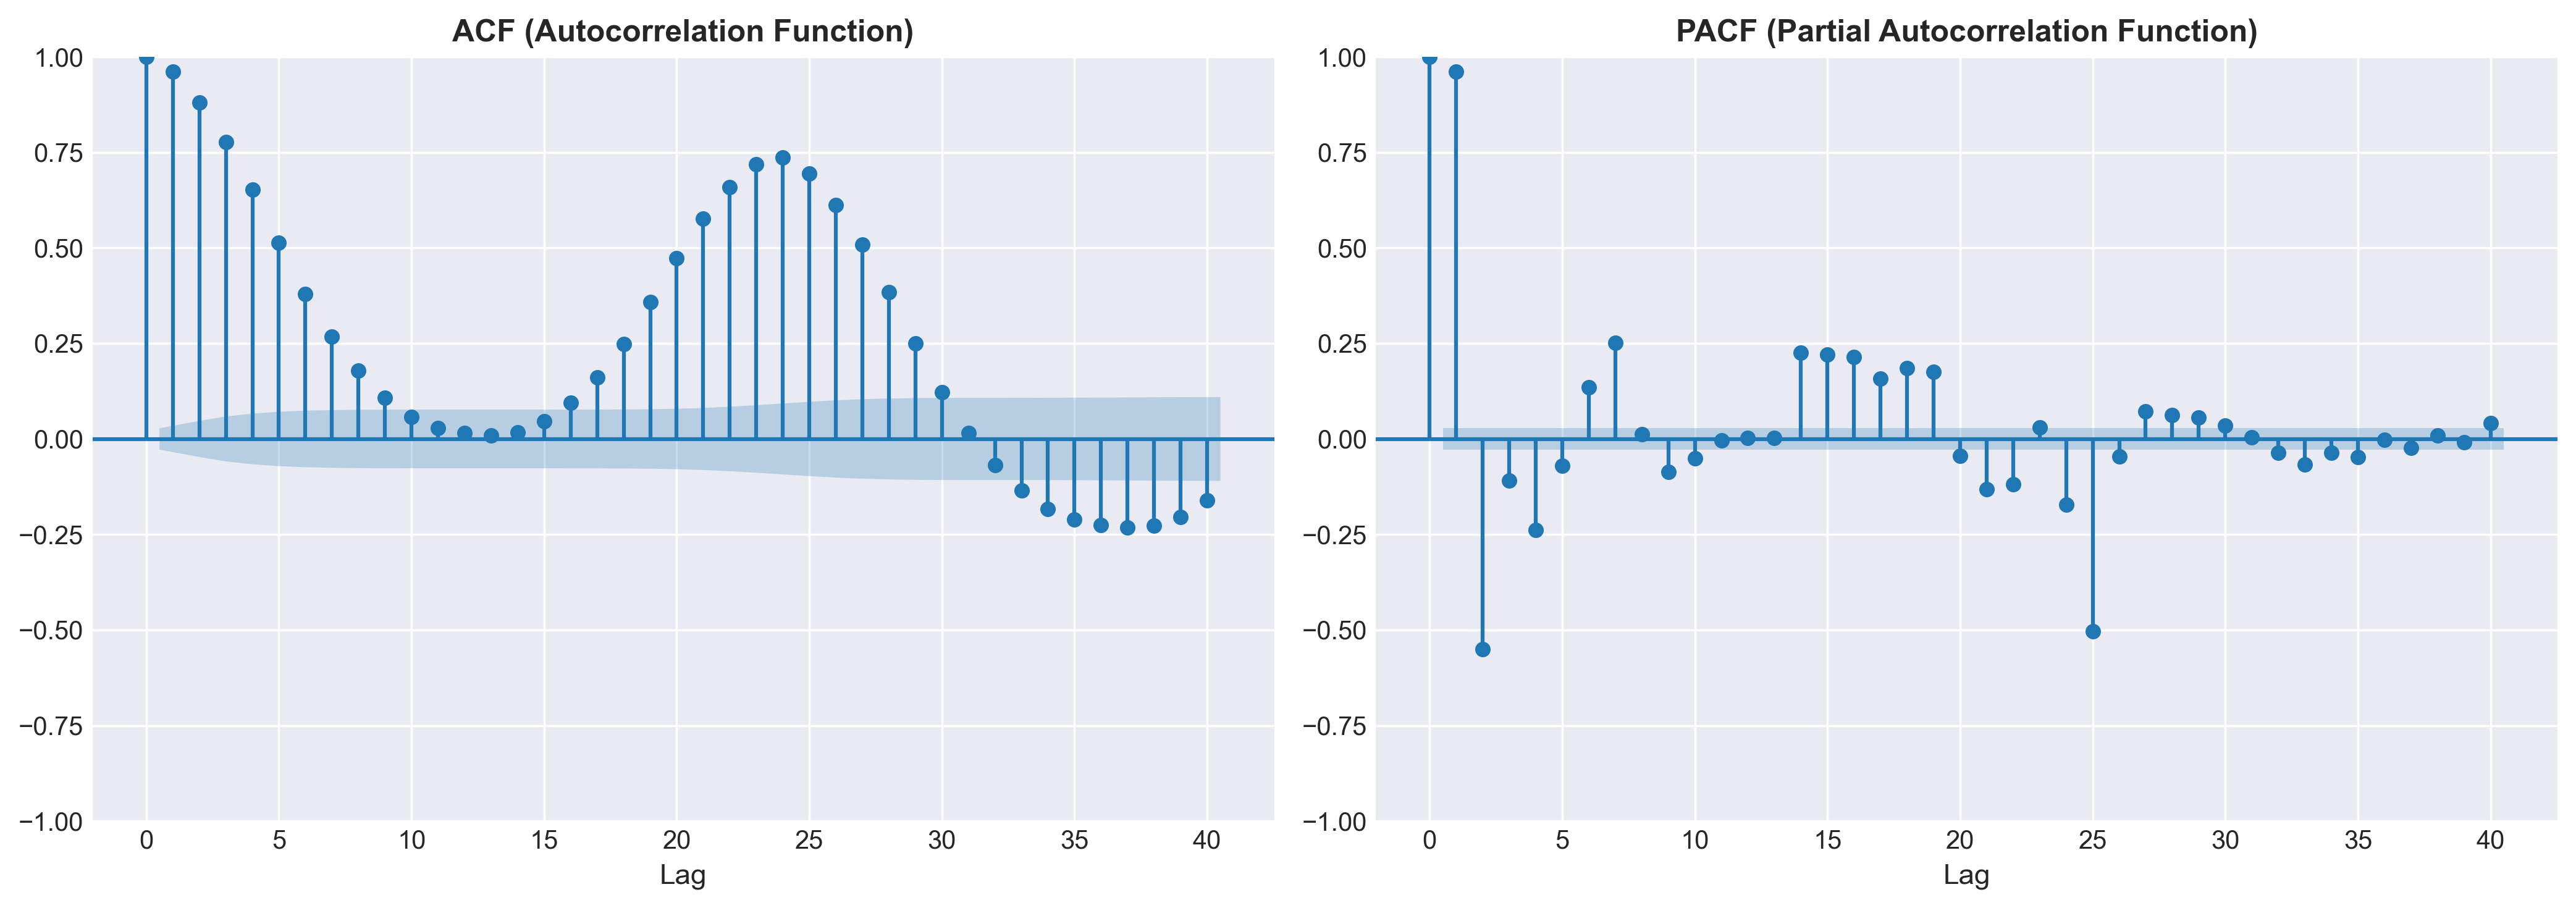

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(14, 5), dpi=300)

# ACF
plt.subplot(1, 2, 1)
plot_acf(df['Sessions'], lags=40, ax=plt.gca())
plt.title('ACF (Autocorrelation Function)', fontsize=12, fontweight='bold')
plt.xlabel('Lag', fontsize=11)

# PACF
plt.subplot(1, 2, 2)
plot_pacf(df['Sessions'], lags=40, method='ywm', ax=plt.gca())
plt.title('PACF (Partial Autocorrelation Function)', fontsize=12, fontweight='bold')
plt.xlabel('Lag', fontsize=11)

plt.tight_layout()
plt.show()

ACF, zaman serisinin kendisiyle geçmiş değerleri arasındaki ilişkisini ölçer. Yani bir günün trafiği, kaç gün önceki trafikle ilişkili olduğunu gösterir.
ACF GrafiĞİ incelendiğinde; Kısa süreli güçlü bir ilişki görülmekte, son saatler birbirine çok bağlı. Günlük tekrar eden bir trafik deseni karışımıza çıkıyor. 
PACF, aradaki gecikmeli değerlerin etkisini kaldırıp, sadece direkt ilişkiyi ölçer. ARIMA modelinin parametrelerini belirlemede çok önemlidir.
PACF Değerleri:
Lag 0:   1.00  
Lag 1:   1e yakın  korelasyon güçlü
Lag 2:  -0.55   negatif olarak güçlü 
Lag 3:   0.15   düşük pozitif
Lag 4+:  0.0  sıfıra yakın değerler. yani buradan şunu anlıyoruz 3 saat ve daha önceki veriler, şu anki trafik üzerinde etkili değil

In [21]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA modeli oluştur ve eğit   --Bunu örnekten aldım
# ARIMA(p, d, q) = ARIMA(5, 1, 2)
model = ARIMA(df['Sessions'], order=(5, 1, 2))
model_fit = model.fit()

# Model özeti
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               Sessions   No. Observations:                 4896
Model:                 ARIMA(5, 1, 2)   Log Likelihood             -100455.651
Date:                Fri, 03 Apr 2026   AIC                         200927.301
Time:                        23:06:43   BIC                         200979.269
Sample:                             0   HQIC                        200945.535
                               - 4896                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2209      0.073     16.727      0.000       1.078       1.364
ar.L2         -0.3382      0.099     -3.422      0.001      -0.532      -0.144
ar.L3          0.1755      0.038      4.582      0.0

In [22]:
import pickle

# Modeli kaydet
with open('arima_model.pkl', 'wb') as f:
    pickle.dump(model_fit, f)

print("✅ Model başarıyla kaydedildi: arima_model.pkl")

# Modeli yükle
with open('arima_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print("✅ Model başarıyla yüklendi!")

✅ Model başarıyla kaydedildi: arima_model.pkl
✅ Model başarıyla yüklendi!


In [24]:
# Test seti üzerinde tahmin yapalım
forecast_result = model_fit.get_forecast(steps=len(test))
forecast_values = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

print(f"Test seti tahminleri (ilk 10):")
print(forecast_values.head(10))

Test seti tahminleri (ilk 10):
4896    1.784949e+09
4897    1.685293e+09
4898    1.579187e+09
4899    1.477858e+09
4900    1.454055e+09
4901    1.484637e+09
4902    1.537130e+09
4903    1.612545e+09
4904    1.712832e+09
4905    1.821792e+09
Name: predicted_mean, dtype: float64


In [42]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Hataları hesapla
mae = mean_absolute_error(df['Sessions'][train_size:], forecast_values)
rmse = np.sqrt(mean_squared_error(df['Sessions'][train_size:], forecast_values))

print("📊 Model Performans Metrikleri:")
print(f"MAE (Ortalama Mutlak Hata): {mae:.2f}")
print(f"RMSE (Karekök Ortalama Kare Hata): {rmse:.2f}")

📊 Model Performans Metrikleri:
MAE (Ortalama Mutlak Hata): 632221868.52
RMSE (Karekök Ortalama Kare Hata): 768528407.84


In [43]:
# Gelecek 7 saat için tahmin 
future_forecast_7 = model_fit.get_forecast(steps=7)
future_values_7 = future_forecast_7.predicted_mean
future_ci_7 = future_forecast_7.conf_int()

# Sonuçları göster
forecast_df_7 = pd.DataFrame({
    'Saat İndeksi': range(len(df), len(df) + 7),
    'Tahmin': future_values_7.values,
    'Alt Sınır': future_ci_7.iloc[:, 0].values,
    'Üst Sınır': future_ci_7.iloc[:, 1].values
})

forecast_df_7

,Saat İndeksi,Tahmin,Alt Sınır,Üst Sınır
0,4896,1.784949e+09,1.397198e+09,2.172700e+09
1,4897,1.685293e+09,1.032456e+09,2.338130e+09
2,4898,1.579187e+09,7.259124e+08,2.432461e+09
3,4899,1.477858e+09,4.344130e+08,2.521304e+09
4,4900,1.454055e+09,2.208697e+08,2.687241e+09
5,4901,1.484637e+09,9.895266e+07,2.870322e+09
6,4902,1.537130e+09,4.128089e+07,3.032979e+09


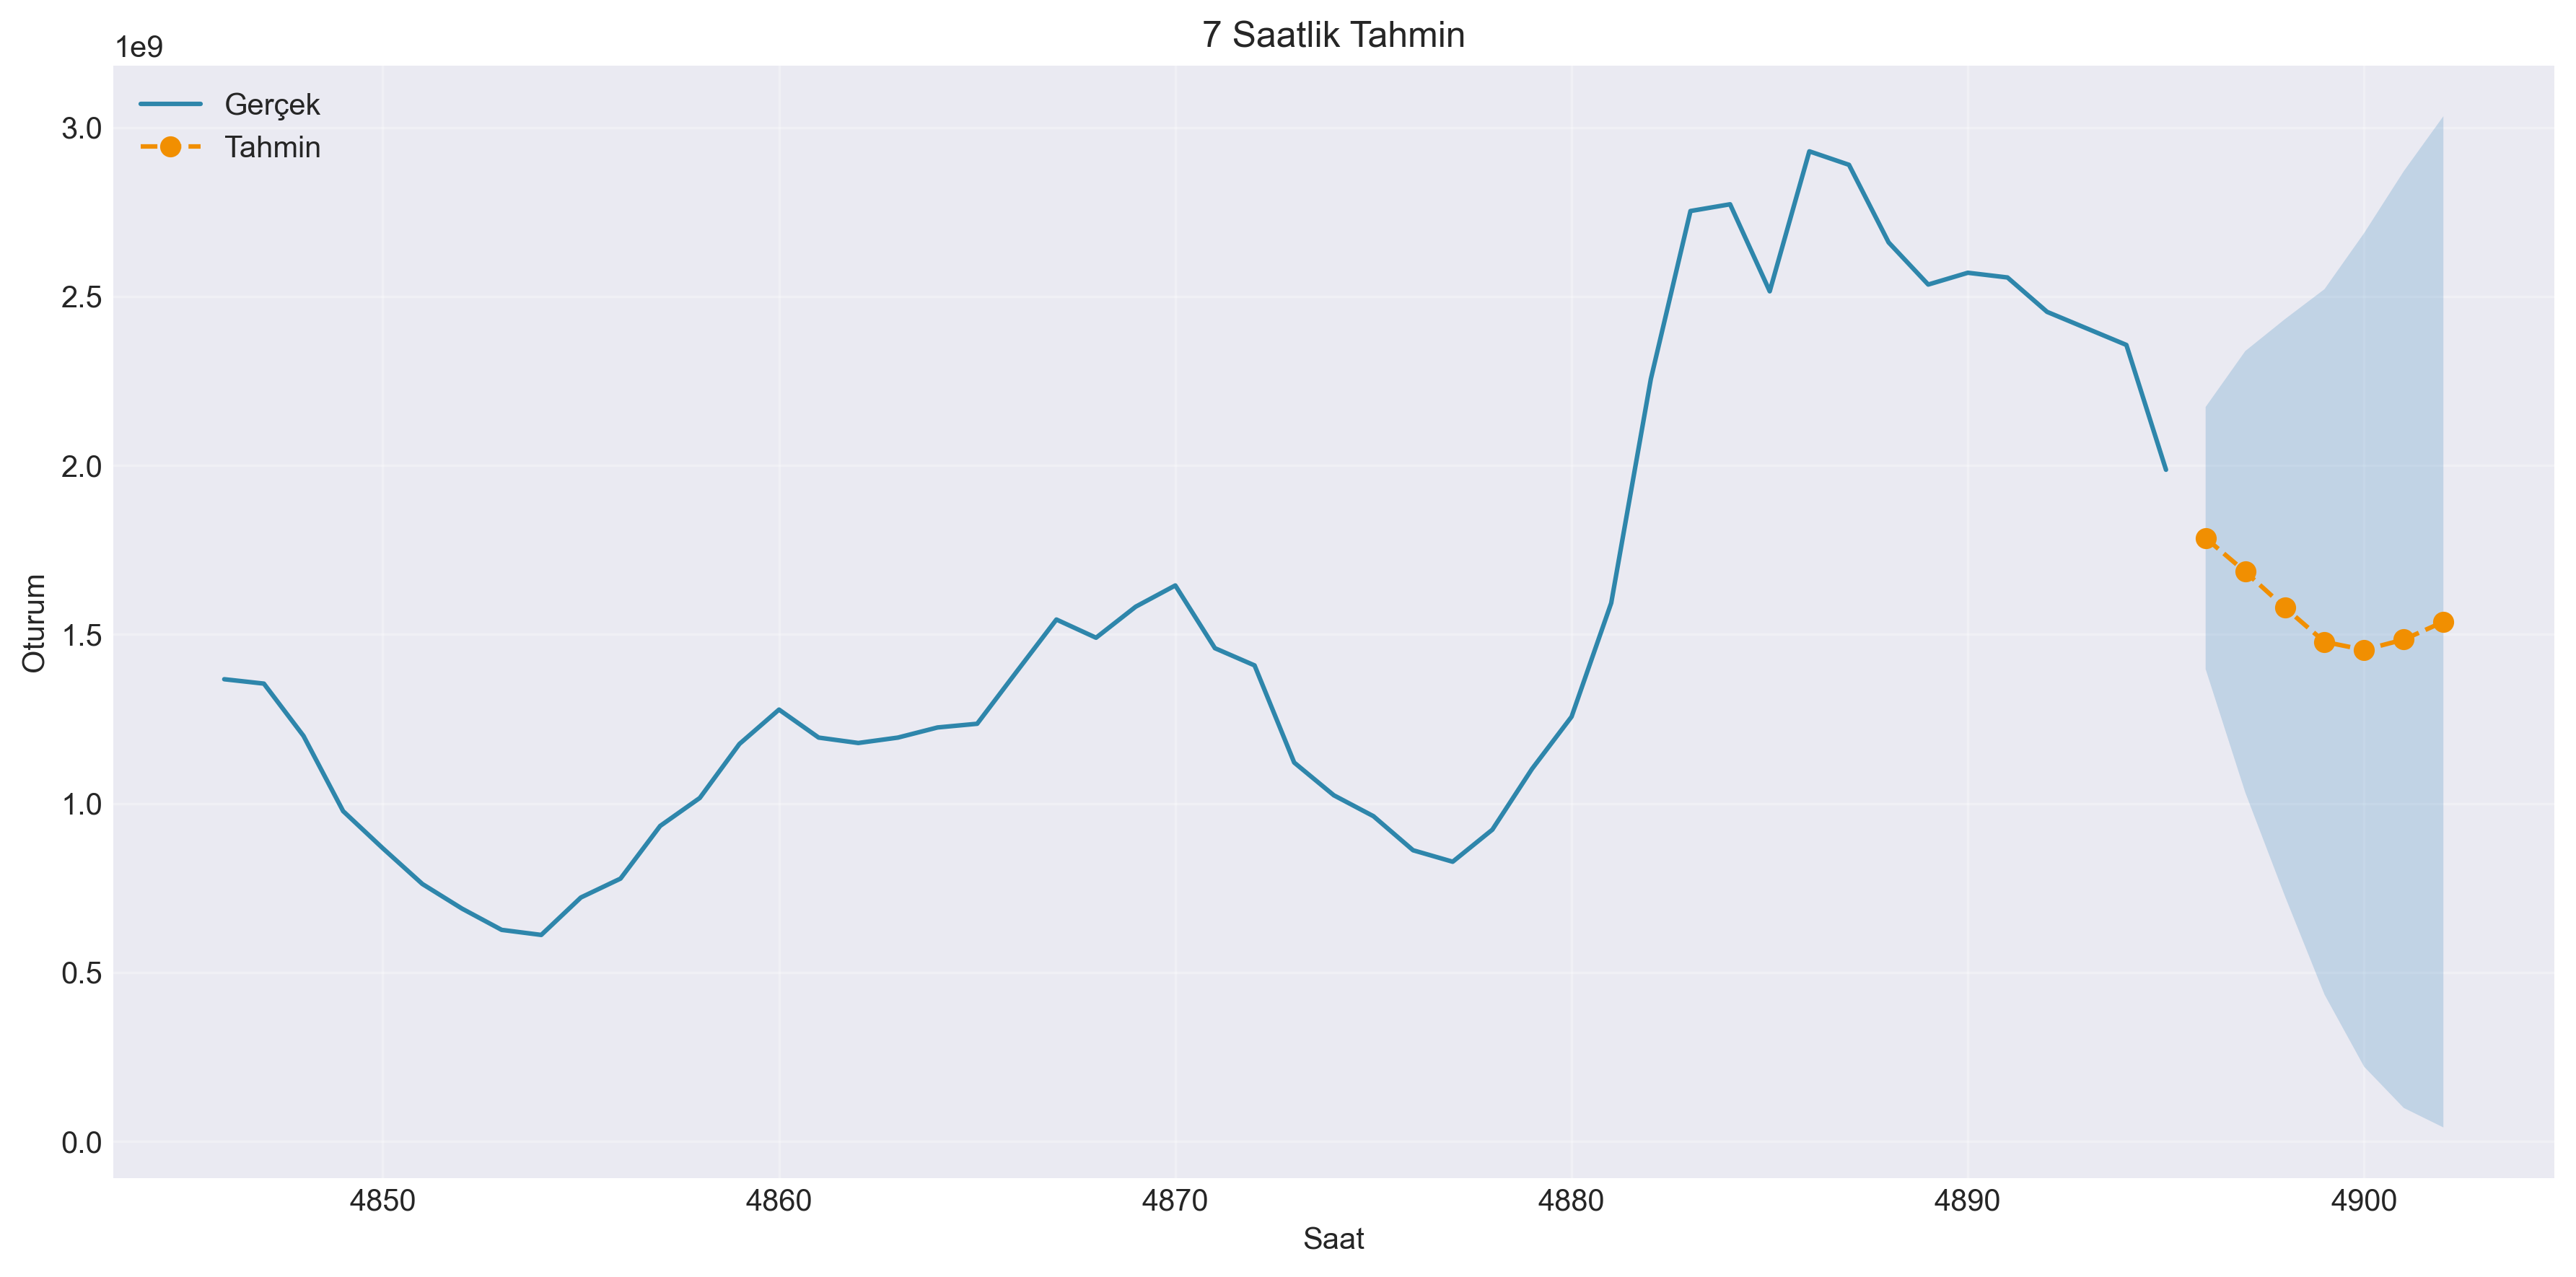

In [31]:
# 7 Saatlik Tahmin Grafiği
plt.figure(figsize=(12,6), dpi=300)

plt.plot(df['Hour Index'][-50:], df['Sessions'][-50:], label='Gerçek', color='#2E86AB')
plt.plot(forecast_df_7['Saat İndeksi'], forecast_df_7['Tahmin'],
         '--o', label='Tahmin', color='#F18F01')

plt.fill_between(forecast_df_7['Saat İndeksi'],
                 forecast_df_7['Alt Sınır'],
                 forecast_df_7['Üst Sınır'],
                 alpha=0.2)

plt.xlabel('Saat')
plt.ylabel('Oturum')
plt.title('7 Saatlik Tahmin')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# Gelecek 30 saat için tahmin
future_forecast_30 = model_fit.get_forecast(steps=30)
future_values_30 = future_forecast_30.predicted_mean
future_ci_30 = future_forecast_30.conf_int()

# Sonuçları göster
forecast_df_30 = pd.DataFrame({
    'Saat İndeksi': range(len(df), len(df) + 30),
    'Tahmin': future_values_30.values,
    'Alt Sınır': future_ci_30.iloc[:, 0].values,
    'Üst Sınır': future_ci_30.iloc[:, 1].values
})

forecast_df_30.head(15)

,Saat İndeksi,Tahmin,Alt Sınır,Üst Sınır
0,4896,1.784949e+09,1.397198e+09,2.172700e+09
1,4897,1.685293e+09,1.032456e+09,2.338130e+09
2,4898,1.579187e+09,7.259124e+08,2.432461e+09
3,4899,1.477858e+09,4.344130e+08,2.521304e+09
4,4900,1.454055e+09,2.208697e+08,2.687241e+09
5,4901,1.484637e+09,9.895266e+07,2.870322e+09
6,4902,1.537130e+09,4.128089e+07,3.032979e+09
7,4903,1.612545e+09,3.824823e+07,3.186843e+09
8,4904,1.712832e+09,8.654990e+07,3.339113e+09
9,4905,1.821792e+09,1.662437e+08,3.477340e+09


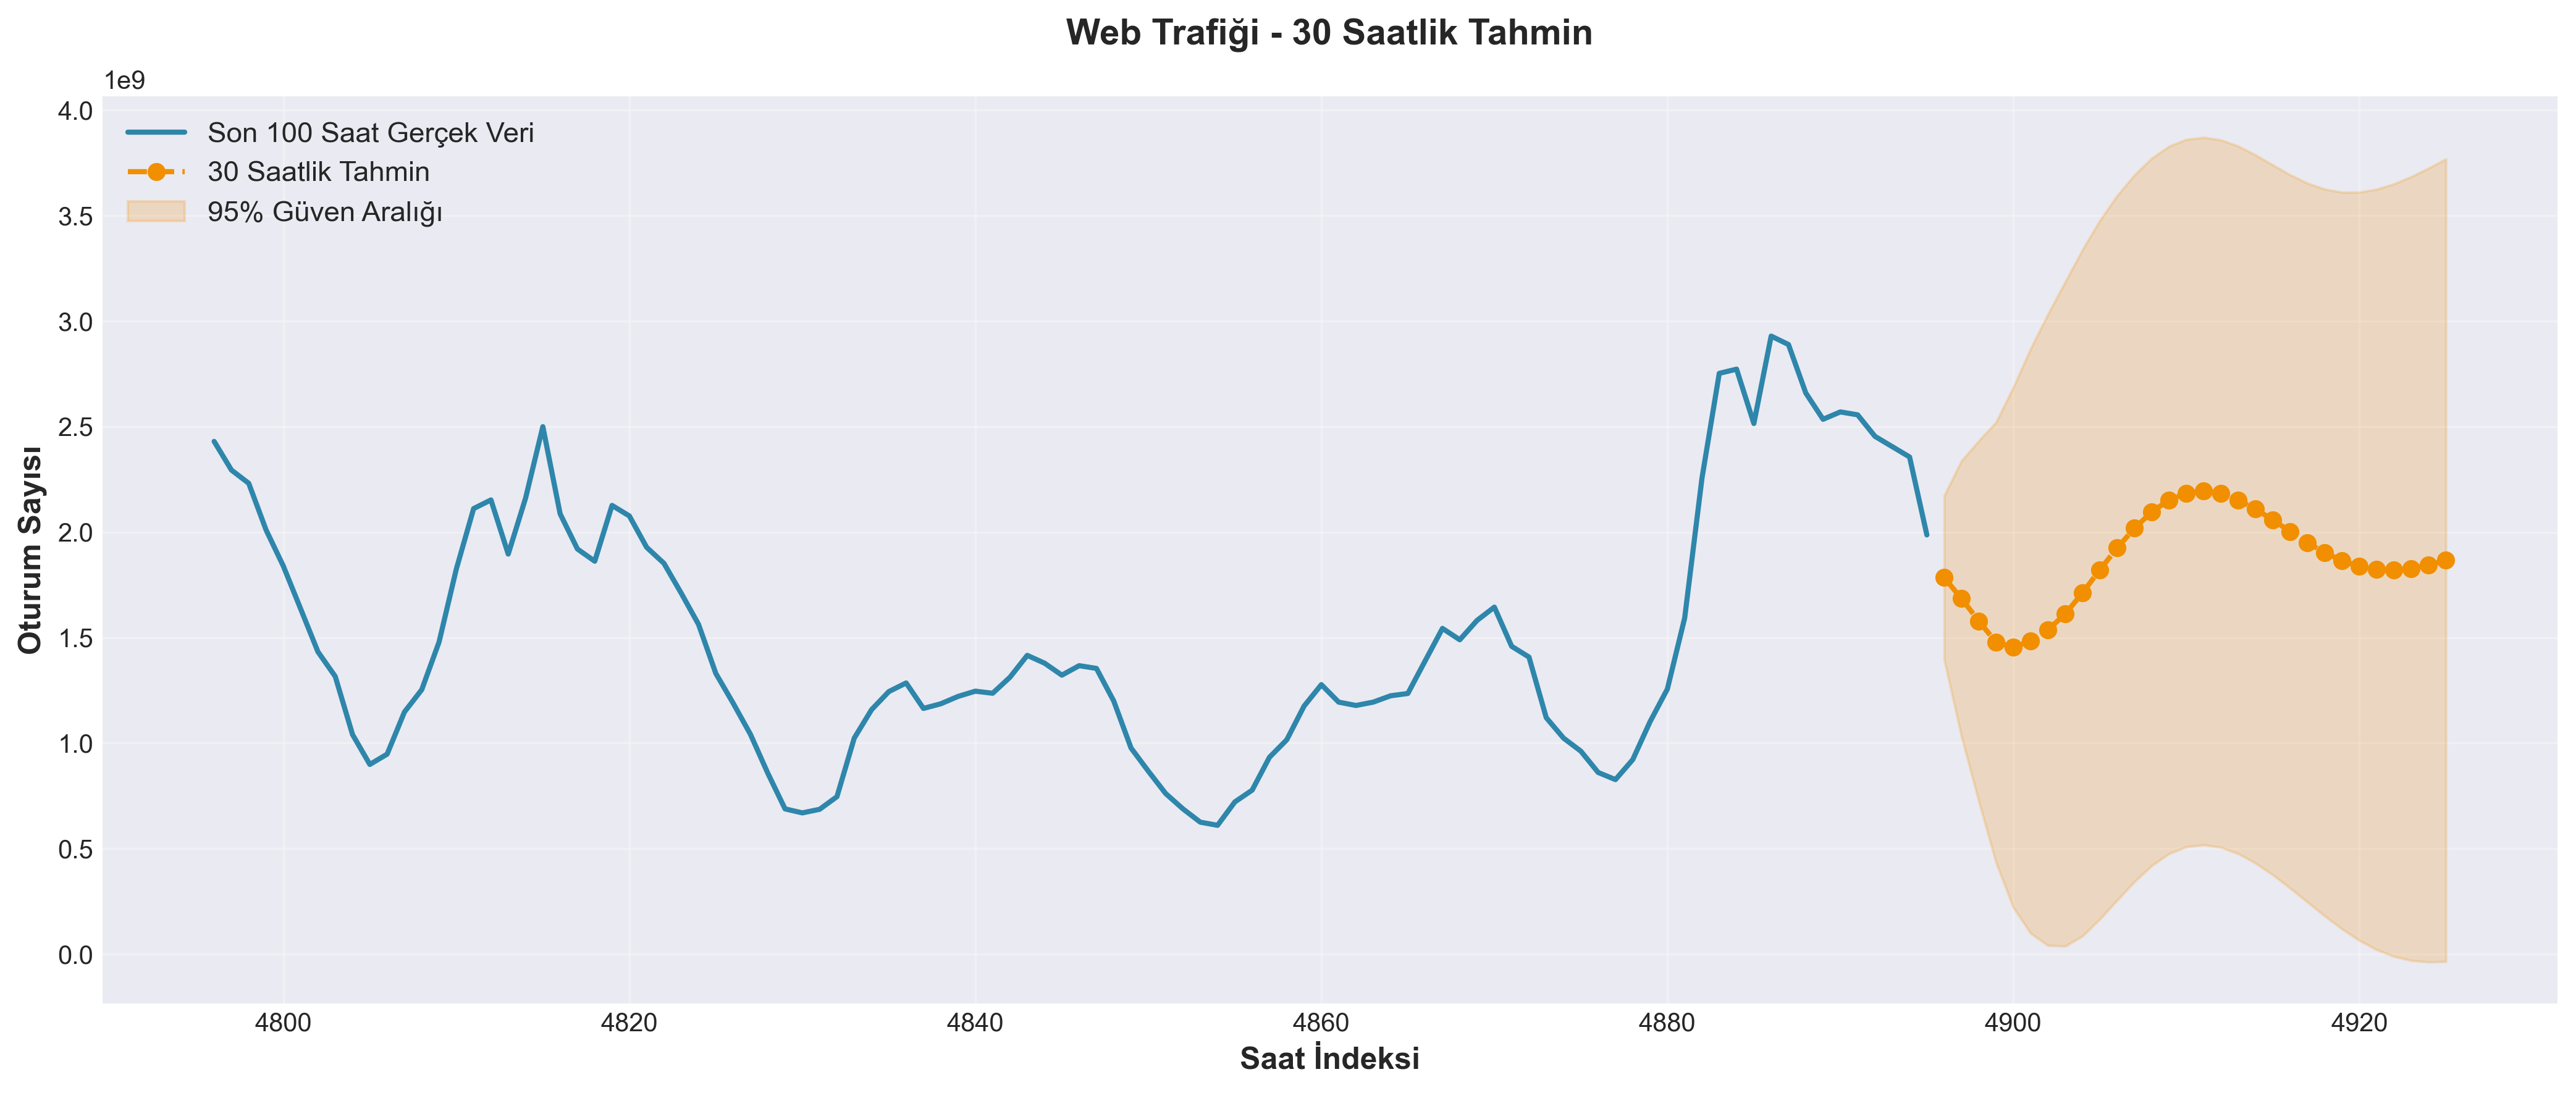

In [34]:
# 30 Saatlik Tahmin Grafiği
plt.figure(figsize=(14, 6), dpi=300)
plt.plot(df['Hour Index'][-100:], df['Sessions'][-100:], 
         label='Son 100 Saat Gerçek Veri', color='#2E86AB', linewidth=2)
plt.plot(forecast_df_30['Saat İndeksi'], forecast_df_30['Tahmin'], 
         label='30 Saatlik Tahmin', color='#F18F01', linewidth=2, linestyle='--', marker='o')
plt.fill_between(forecast_df_30['Saat İndeksi'], 
                  forecast_df_30['Alt Sınır'], 
                  forecast_df_30['Üst Sınır'], 
                  alpha=0.2, color='#F18F01', label='95% Güven Aralığı')
plt.xlabel('Saat İndeksi', fontsize=12, fontweight='bold')
plt.ylabel('Oturum Sayısı', fontsize=12, fontweight='bold')
plt.title('Web Trafiği - 30 Saatlik Tahmin', fontsize=14, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()